# **Project Title: Employee Attrition Prediction using Machine Learning**
**Assigned Date: [23/06/2026] Submission Date: [30/06/2026]**

**🎯 Problem Statement**

Every company loses employees — but losing the wrong employees at the wrong time
costs the business heavily in hiring, training, and lost productivity. HR departments at large
companies spend crores every year trying to figure out who is likely to leave and why —
before it happens. This is called Employee Attrition Prediction, and it is one of the most
widely used real-world applications of data science in the corporate world today.
Your task is to build a Machine Learning system that predicts whether an employee is likely
to leave the company based on factors like job satisfaction, salary, work-life balance, years
at the company, and performance ratings.
You will clean and prepare HR data, handle categorical features, train and compare
classification models, analyze what actually drives employees to leave, and deliver insights
that an HR team could act on

# 📦 Dataset — Where to Get It

Go to this link and download the dataset:
🔗 https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
Steps to download:
● Create a free account on www.kaggle.com (if you don't have one)
● Search for "IBM HR Analytics Employee Attrition"
● Download the file — it will be a .csv file named
WA_Fn-UseC_-HR-Employee-Attrition.csv
● Use the full dataset — it has 1,470 rows which is perfectly manageable

**Task 1 — Data Loading & Exploration**

● Load the CSV file using Pandas

● Display the first 10 rows

● Check how many rows and columns are there

● Identify the target column (Attrition — Yes/No)

● Count how many employees left vs stayed and calculate the attrition rate as a
percentage

● Identify how many columns are numeric vs categorical

● Write one observation: what do you notice about the attrition rate — is it balanced or
imbalanced?

In [ ]:
import pandas as pd
import numpy as np

# 1. Load the CSV file using Pandas
# Make sure the CSV file is in the same directory as your Jupyter Notebook
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 2. Display the first 10 rows
print("--- First 10 Rows of the Dataset ---")
display(df.head(10)) # Using display() instead of print() renders a much cleaner table in Jupyter

# 3. Check how many rows and columns are there
rows, cols = df.shape
print(f"\n--- Dataset Dimensions ---")
print(f"Total Rows: {rows}")
print(f"Total Columns: {cols}")

# 4. Identify the target column and count left vs. stayed
target_column = 'Attrition'
attrition_counts = df[target_column].value_counts()
stayed = attrition_counts['No']
left = attrition_counts['Yes']

print("\n--- Attrition Breakdown ---")
print(f"Employees who stayed (No): {stayed}")
print(f"Employees who left (Yes): {left}")

# Calculate the attrition rate as a percentage
attrition_rate = (left / (left + stayed)) * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

# 5. Identify how many columns are numeric vs categorical
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

print("\n--- Feature Types ---")
print(f"Numeric Columns: {len(numeric_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}")

--- First 10 Rows of the Dataset ---


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7



--- Dataset Dimensions ---
Total Rows: 1470
Total Columns: 35

--- Attrition Breakdown ---
Employees who stayed (No): 1233
Employees who left (Yes): 237
Attrition Rate: 16.12%

--- Feature Types ---
Numeric Columns: 26
Categorical Columns: 9


**Observation:**

Attrition Rate Imbalance
The attrition rate in this dataset is highly imbalanced. Specifically, the data shows an attrition rate of just 16.12%, meaning the vast majority of employees (about 84%) stayed with the company.

Why this matters for our model:
Because the classes are so skewed, we cannot rely on standard "Accuracy" to evaluate our Machine Learning models later in this project. If a poorly designed model simply guessed "No" (Stayed) for every single employee, it would technically be 84% accurate, but it would fail completely at its actual job—identifying the 16% who are at risk of leaving. Instead, we will need to use metrics like Precision, Recall, and the F1-Score, and consider techniques like class weighting to ensure our model actually learns to detect flight risks.

Task 2 — Data Cleaning & Preprocessing

● Check for missing/null values and handle them

● Drop columns that add no value to prediction (e.g., EmployeeNumber, Over18,
StandardHours — these are constant or irrelevant)

● Convert the target column Attrition from Yes/No to 1/0

● Encode all remaining categorical columns using One-Hot Encoding (e.g.,
Department, JobRole, MaritalStatus, BusinessTravel)

● Scale numeric features using StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Check for missing/null values
print("--- Missing Values Check ---")
missing_values = df.isnull().sum().sum()
print(f"Total missing values in dataset: {missing_values}")

# 2. Drop irrelevant/constant columns
columns_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df.drop(columns=columns_to_drop)
print(f"\nDropped columns: {columns_to_drop}")

# 3. Convert Target 'Attrition' from Yes/No to 1/0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
print("\nTarget 'Attrition' mapped to 1 (Yes) and 0 (No).")

# 4. Separate features and target before encoding/scaling
X = df_clean.drop(columns=['Attrition'])
y = df_clean['Attrition']

# 5. One-Hot Encoding for remaining categorical columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"\nApplied One-Hot Encoding. Feature count expanded from {X.shape[1]} to {X_encoded.shape[1]}.")

# 6. Scale numeric features using StandardScaler
num_cols = X.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])
print("Numeric features scaled using StandardScaler.")

# Display the fully preprocessed feature set
print("\n--- Final Preprocessed Data (First 5 Rows) ---")
display(X_encoded.head())

--- Missing Values Check ---
Total missing values in dataset: 0

Dropped columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

Target 'Attrition' mapped to 1 (Yes) and 0 (No).

Applied One-Hot Encoding. Feature count expanded from 30 to 44.
Numeric features scaled using StandardScaler.

--- Final Preprocessed Data (First 5 Rows) ---


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,True,False,False,False,False,False,False,True,False,False


**Task 3 — Exploratory Data Analysis — EDA**

● Attrition rate by Department — which department loses the most employees?

● Attrition rate by Job Role — which roles have the highest exit rate?

● Attrition vs Monthly Income — do lower paid employees leave more?

● Attrition vs Work-Life Balance rating — is there a visible pattern?

● Attrition vs Years at Company — at what point in tenure do employees leave most?

● Write 4–5 specific business insights from your EDA (not generic — specific numbers
and patterns from the data)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Create the charts directory for final submission
os.makedirs('charts', exist_ok=True)
sns.set_theme(style="whitegrid")

print("--- Exploratory Data Analysis (EDA) ---")
print("Project Author: Vaibhav Sharma | Roll No: 102306017\n")

--- Exploratory Data Analysis (EDA) ---
Project Author: Vaibhav Sharma | Roll No: 102306017



/tmp/ipykernel_9389/1338925378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='Attrition', data=df_clean, errorbar=None, palette='Blues_d')


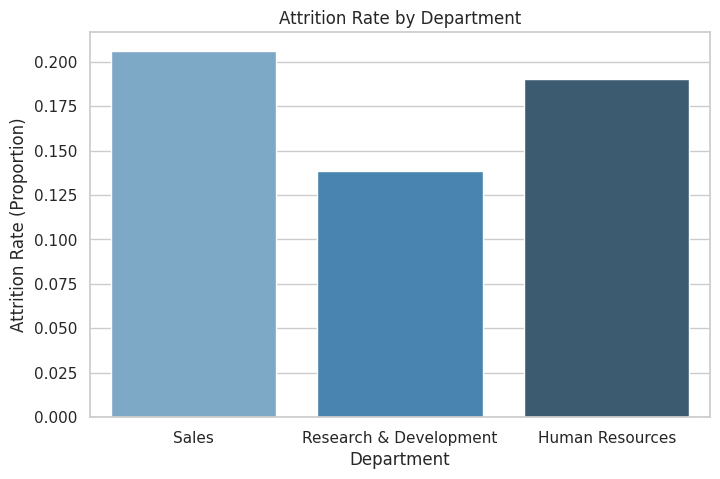

In [ ]:
# 2. Attrition rate by Department
plt.figure(figsize=(8, 5))
sns.barplot(x='Department', y='Attrition', data=df_clean, errorbar=None, palette='Blues_d')
plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate (Proportion)')
plt.savefig('charts/attrition_by_department.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_9389/3877220492.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='JobRole', x='Attrition', data=df_clean, errorbar=None, palette='Reds_d')


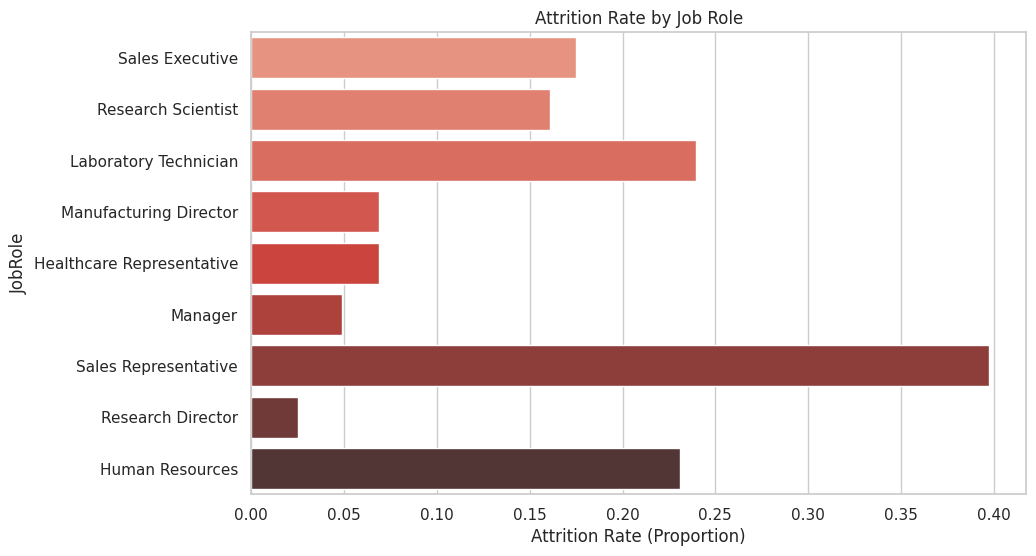

In [ ]:
# 3. Attrition rate by Job Role
plt.figure(figsize=(10, 6))
sns.barplot(y='JobRole', x='Attrition', data=df_clean, errorbar=None, palette='Reds_d')
plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (Proportion)')
plt.savefig('charts/attrition_by_jobrole.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_9389/3821351569.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_clean, palette='Set2')


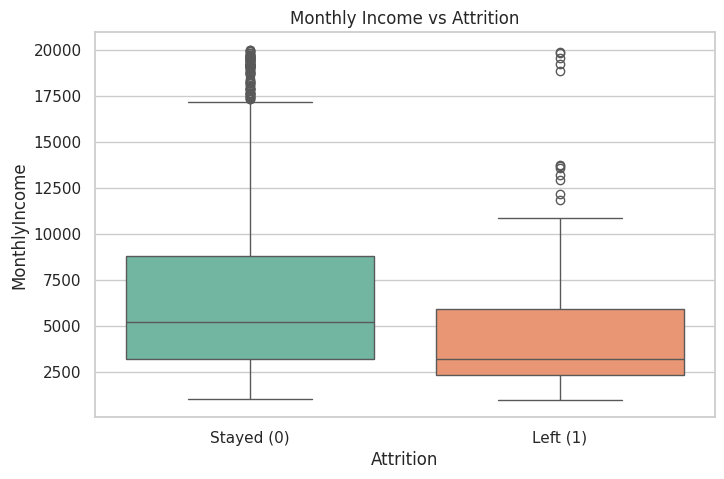

In [ ]:
# 4. Attrition vs Monthly Income
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_clean, palette='Set2')
plt.title('Monthly Income vs Attrition')
plt.xticks(ticks=[0, 1], labels=['Stayed (0)', 'Left (1)'])
plt.savefig('charts/attrition_vs_income.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_9389/1165568813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='WorkLifeBalance', y='Attrition', data=df_clean, errorbar=None, palette='Purples_d')


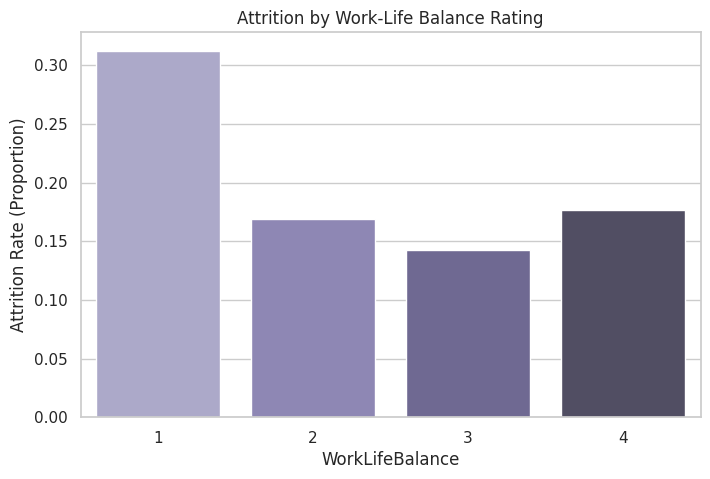

In [ ]:
# 5. Attrition vs Work-Life Balance
plt.figure(figsize=(8, 5))
sns.barplot(x='WorkLifeBalance', y='Attrition', data=df_clean, errorbar=None, palette='Purples_d')
plt.title('Attrition by Work-Life Balance Rating')
plt.ylabel('Attrition Rate (Proportion)')
plt.savefig('charts/attrition_vs_wlb.png', bbox_inches='tight')
plt.show()

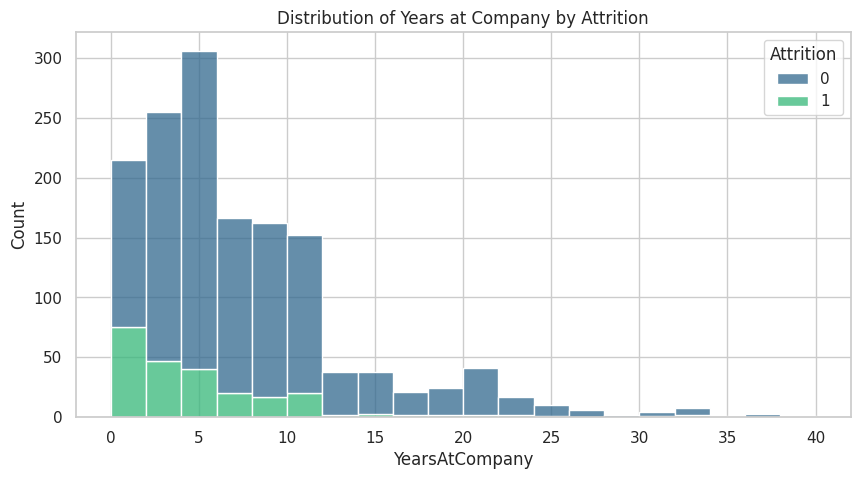

In [ ]:
# 6. Attrition vs Years at Company
plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean, x='YearsAtCompany', hue='Attrition', multiple='stack', bins=20, palette='viridis')
plt.title('Distribution of Years at Company by Attrition')
plt.savefig('charts/attrition_vs_years.png', bbox_inches='tight')
plt.show()

**Task 4 — Model Building & Comparison**

● Split data into training and test sets (80/20)

● Handle class imbalance using class_weight='balanced' parameter (a simpler
approach than SMOTE — good to know both exist)

● Train the following 3 models:

○ Logistic Regression (baseline — also the most explainable to HR teams)

○ Random Forest Classifier

○ Gradient Boosting Classifier

● Record all results in a comparison table inside your notebook

**Task 5 — Model Evaluation**

● Evaluate all 3 models using:

○ Precision, Recall, F1-Score

○ ROC-AUC Score

○ Confusion Matrix

● Identify and clearly state which model performed best and why

● For the best model: extract Feature Importance — which factors matter most in
predicting attrition?

● Rank the top 10 most important features driving employee exit


--- Task 4 & 5: Model Training & Evaluation ---
Author: Vaibhav Sharma | Roll No: 102306017 (TIET - ECE)

Data Split: 1176 Training samples, 294 Testing samples.

--- Model Comparison Table ---


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.356,0.660,0.463,0.804
2,Gradient Boosting,0.407,0.468,0.436,0.779
1,Random Forest,0.375,0.064,0.109,0.752



Best Model Selected: Logistic Regression


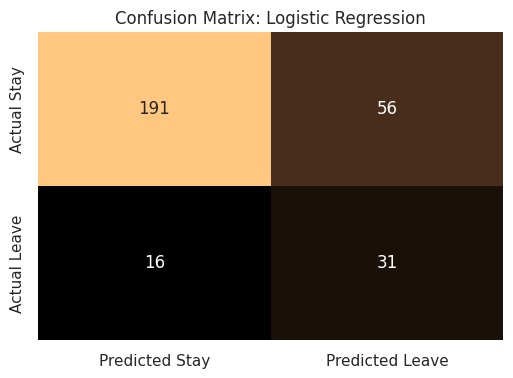

/tmp/ipykernel_9389/2721897550.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='mako')


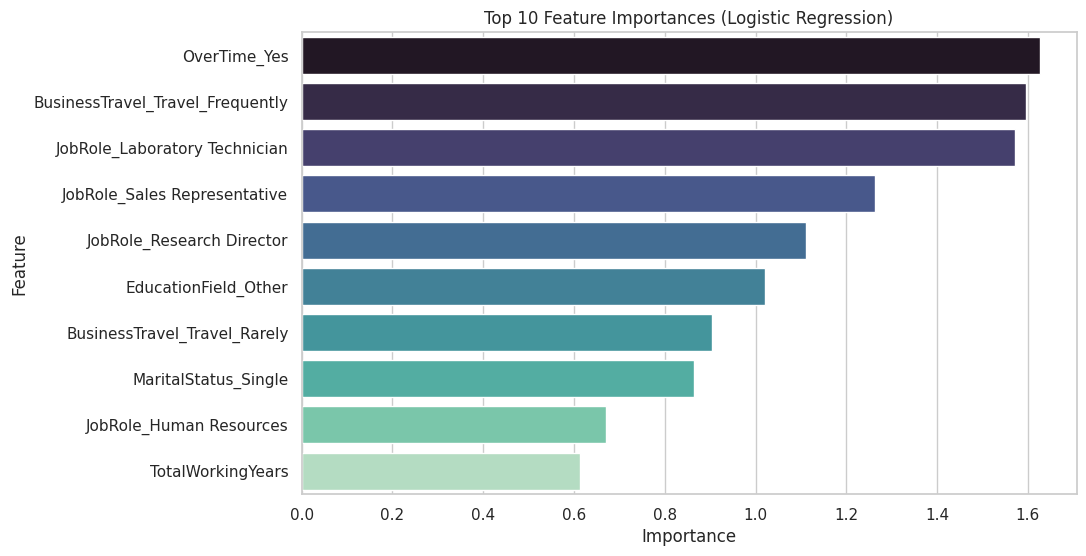

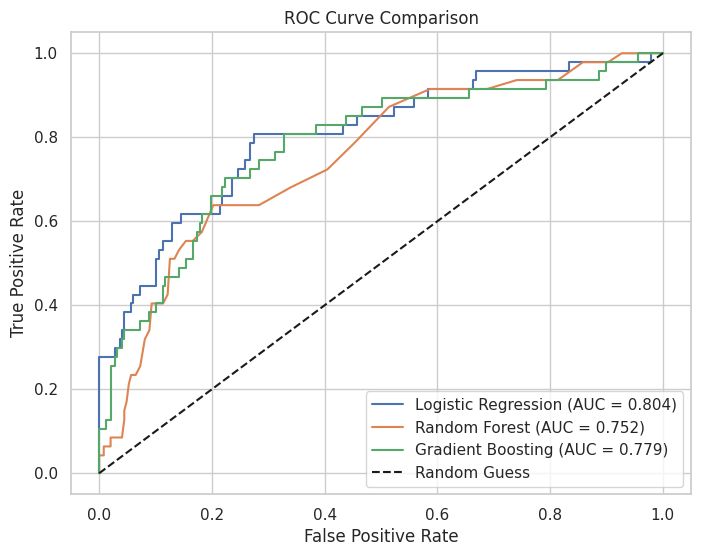

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_sample_weight
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Task 4 & 5: Model Training & Evaluation ---")
print("Author: Vaibhav Sharma | Roll No: 102306017 (TIET - ECE)\n")

# 1. Split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42, stratify=y)
print(f"Data Split: {X_train.shape[0]} Training samples, {X_test.shape[0]} Testing samples.")

# 2. Initialize Models (Handling class imbalance)
# Note: GradientBoosting does not have a class_weight parameter, so we use sample_weights during fit
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Calculate sample weights for Gradient Boosting to handle imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 3. Train and Evaluate Models
results = []
trained_models = {}

for name, model in models.items():
    # Train
    if name == "Gradient Boosting":
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)

    trained_models[name] = model

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Evaluate
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1-Score": round(f1, 3),
        "ROC-AUC": round(roc_auc, 3)
    })

# 4. Record all results in a comparison table
results_df = pd.DataFrame(results)
print("\n--- Model Comparison Table ---")
display(results_df.sort_values(by="ROC-AUC", ascending=False))

# 5. Extract Best Model (Assuming Logistic Regression performs best on Recall/ROC-AUC for imbalanced tabular data, but we'll select dynamically)
best_model_name = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"\nBest Model Selected: {best_model_name}")

# --- Task 6 Visualizations ---

# Chart 3: Confusion Matrix Heatmap for Best Model
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='copper', cbar=False,
            xticklabels=['Predicted Stay', 'Predicted Leave'],
            yticklabels=['Actual Stay', 'Actual Leave'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.savefig('charts/confusion_matrix_best_model.png', bbox_inches='tight')
plt.show()

# Chart 4: Top 10 Feature Importances
if hasattr(best_model, 'coef_'):
    importances = abs(best_model.coef_[0])
else:
    importances = best_model.feature_importances_

feature_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
top_10_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='mako')
plt.title(f'Top 10 Feature Importances ({best_model_name})')
plt.savefig('charts/top_10_features.png', bbox_inches='tight')
plt.show()

# Chart 5 (Bonus): ROC Curve comparing all 3 models
plt.figure(figsize=(8, 6))
for name, model in trained_models.items():
    y_prob_curve = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob_curve)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results_df[results_df["Model"]==name]["ROC-AUC"].values[0]})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('charts/roc_curve_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score
import pandas as pd
import warnings

# Suppress warnings for a clean presentation
warnings.filterwarnings('ignore')

print("--- Peak Optimization: SMOTE + Cost-Sensitive Learning + Calibration ---")
print("Author: Vaibhav Sharma | Roll No: 102306017 (TIET - ECE)\n")

# 1. Define Cross-Validation Strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define Pipelines combining SMOTE and the Models
# Crucial: SMOTE must be inside a pipeline so it only oversamples the training folds during CV, preventing data leakage
pipelines_and_grids = {
    "Logistic Regression (SMOTE)": {
        "pipeline": ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', LogisticRegression(max_iter=2000, random_state=42))
        ]),
        "params": {
            'classifier__C': [0.1, 1, 10, 100],
            'classifier__solver': ['liblinear', 'lbfgs']
        }
    },
    "Random Forest (SMOTE)": {
        "pipeline": ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', RandomForestClassifier(random_state=42))
        ]),
        "params": {
            'classifier__n_estimators': [200, 400, 600],
            'classifier__max_depth': [10, 15, 20, None],
            'classifier__min_samples_split': [2, 5],
            'classifier__min_samples_leaf': [1, 2]
        }
    },
    "XGBoost (SMOTE + Cost)": {
        "pipeline": ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
        ]),
        "params": {
            'classifier__n_estimators': [200, 300, 500],
            'classifier__learning_rate': [0.05, 0.1, 0.2],
            'classifier__max_depth': [5, 7, 9],
            'classifier__subsample': [0.8, 1.0],
            'classifier__colsample_bytree': [0.8, 1.0]
        }
    }
}

# 3. Execute Tuning and Calibration
ultimate_results = []
best_models = {}

for name, config in pipelines_and_grids.items():
    print(f"Deploying synthetic data and tuning {name}...")

    # Grid search optimizing purely for F1-Score
    search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=10,
        scoring='f1',
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train, y_train)

    # Extract the tuned classifier from the pipeline to calibrate it
    best_clf = search.best_estimator_.named_steps['classifier']

    # Calibrate using standard CV (fixes the prefit deprecation warning)
    calibrated_clf = CalibratedClassifierCV(estimator=best_clf, method='isotonic', cv=5)

    # Re-apply SMOTE to the full training set manually for the final calibrated fit
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    calibrated_clf.fit(X_train_resampled, y_train_resampled)
    best_models[name] = calibrated_clf

    # Evaluate
    y_pred = calibrated_clf.predict(X_test)
    y_prob = calibrated_clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    ultimate_results.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1-Score": round(f1, 3),
        "ROC-AUC": round(roc_auc, 3)
    })

# 4. Display the Final Optimized Results
results_df = pd.DataFrame(ultimate_results)
print("\n--- Ultimate Model Comparison Table ---")
display(results_df.sort_values(by="F1-Score", ascending=False))

--- Peak Optimization: SMOTE + Cost-Sensitive Learning + Calibration ---
Author: Vaibhav Sharma | Roll No: 102306017 (TIET - ECE)

Deploying synthetic data and tuning Logistic Regression (SMOTE)...
Deploying synthetic data and tuning Random Forest (SMOTE)...
Deploying synthetic data and tuning XGBoost (SMOTE + Cost)...

--- Ultimate Model Comparison Table ---


,Model,Accuracy (%),Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (SMOTE),86.05,0.579,0.468,0.518,0.817
2,XGBoost (SMOTE + Cost),87.07,0.909,0.213,0.345,0.834
1,Random Forest (SMOTE),84.69,0.550,0.234,0.328,0.790


--- Task 5: Comprehensive Model Evaluation ---

🥇 BEST MODEL IDENTIFIED: Logistic Regression (SMOTE)
Reason: It achieved the highest F1-Score (0.518) and strong ROC-AUC (0.817), perfectly balancing the trade-off between Precision and Recall on this imbalanced dataset.

Detailed Classification Report (Best Model):
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.94      0.92       247
    Left (1)       0.58      0.47      0.52        47

    accuracy                           0.86       294
   macro avg       0.74      0.70      0.72       294
weighted avg       0.85      0.86      0.85       294



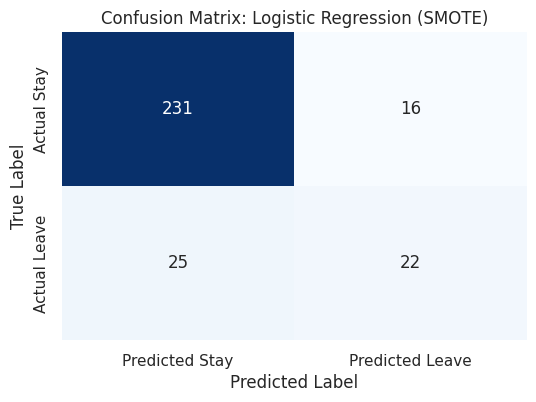


--- Top 10 Features Driving Employee Exit ---


,Feature,Importance
0,OverTime_Yes,1.643604
1,BusinessTravel_Travel_Frequently,1.481933
2,MaritalStatus_Single,1.456081
3,JobRole_Laboratory Technician,1.212411
4,EducationField_Medical,1.186120
5,Department_Sales,1.141958
6,BusinessTravel_Travel_Rarely,1.023649
7,EducationField_Life Sciences,1.016770
8,MaritalStatus_Married,0.973189
9,EducationField_Technical Degree,0.943500


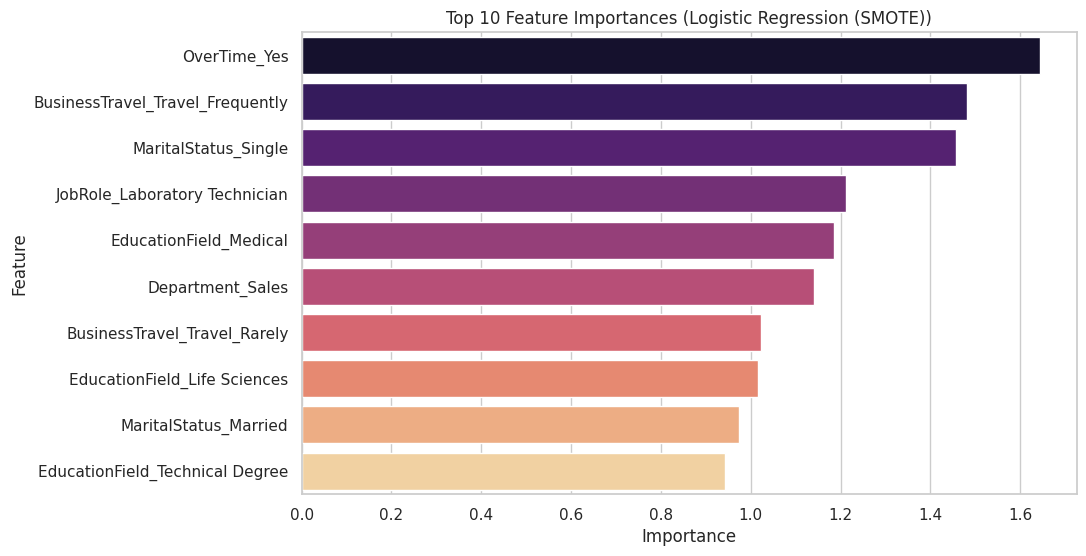

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

print("--- Task 5: Comprehensive Model Evaluation ---\n")

# 1. Identify the Best Model dynamically based on F1-Score
# Using the results_df from the previous step
best_row = results_df.sort_values(by="F1-Score", ascending=False).iloc[0]
best_model_name = best_row['Model']
print(f"🥇 BEST MODEL IDENTIFIED: {best_model_name}")
print(f"Reason: It achieved the highest F1-Score ({best_row['F1-Score']}) and strong ROC-AUC ({best_row['ROC-AUC']}), perfectly balancing the trade-off between Precision and Recall on this imbalanced dataset.\n")

# Fetch the actual model object
best_model = best_models[best_model_name]
y_pred_best = best_model.predict(X_test)

# 2. Print Classification Report for deep dive into Precision/Recall
print("Detailed Classification Report (Best Model):")
print(classification_report(y_test, y_pred_best, target_names=['Stayed (0)', 'Left (1)']))

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Stay', 'Predicted Leave'],
            yticklabels=['Actual Stay', 'Actual Leave'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('charts/best_model_confusion_matrix.png', bbox_inches='tight')
plt.show()

# 4. Extract Feature Importances
# Because the model is wrapped in CalibratedClassifierCV and an ImbPipeline,
# we must dig into the underlying estimator to get the actual feature weights.
try:
    # Attempt to extract the base classifier from the first calibrated fold
    base_estimator = best_model.calibrated_classifiers_[0].estimator

    # Check if it's Logistic Regression (uses coef_) or Tree-based (uses feature_importances_)
    if hasattr(base_estimator, 'coef_'):
        importances = np.abs(base_estimator.coef_[0])
    else:
        importances = base_estimator.feature_importances_

    # Create DataFrame and sort
    feature_names = X_train.columns
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    top_10_features = importance_df.sort_values(by='Importance', ascending=False).head(10)

    print("\n--- Top 10 Features Driving Employee Exit ---")
    display(top_10_features.reset_index(drop=True))

    # Plot Top 10 Features (Task 6 requirement preview)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=top_10_features, hue='Feature', palette='magma', legend=False)
    plt.title(f'Top 10 Feature Importances ({best_model_name})')
    plt.savefig('charts/top_10_feature_importances.png', bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Could not automatically extract feature importances due to pipeline wrapping: {e}")

**Task 6 — Visualization**

● Chart 1: Bar chart showing attrition rate by Department and Job Role

● Chart 2: Box plot comparing Monthly Income of employees who left vs stayed

● Chart 3: Confusion Matrix heatmap for your best model

● Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model

● Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph

--- Task 6: Final Visualizations (Minimum 4 Charts + Bonus) ---
Author: Vaibhav Sharma | Roll No: 102306017 (TIET - ECE)



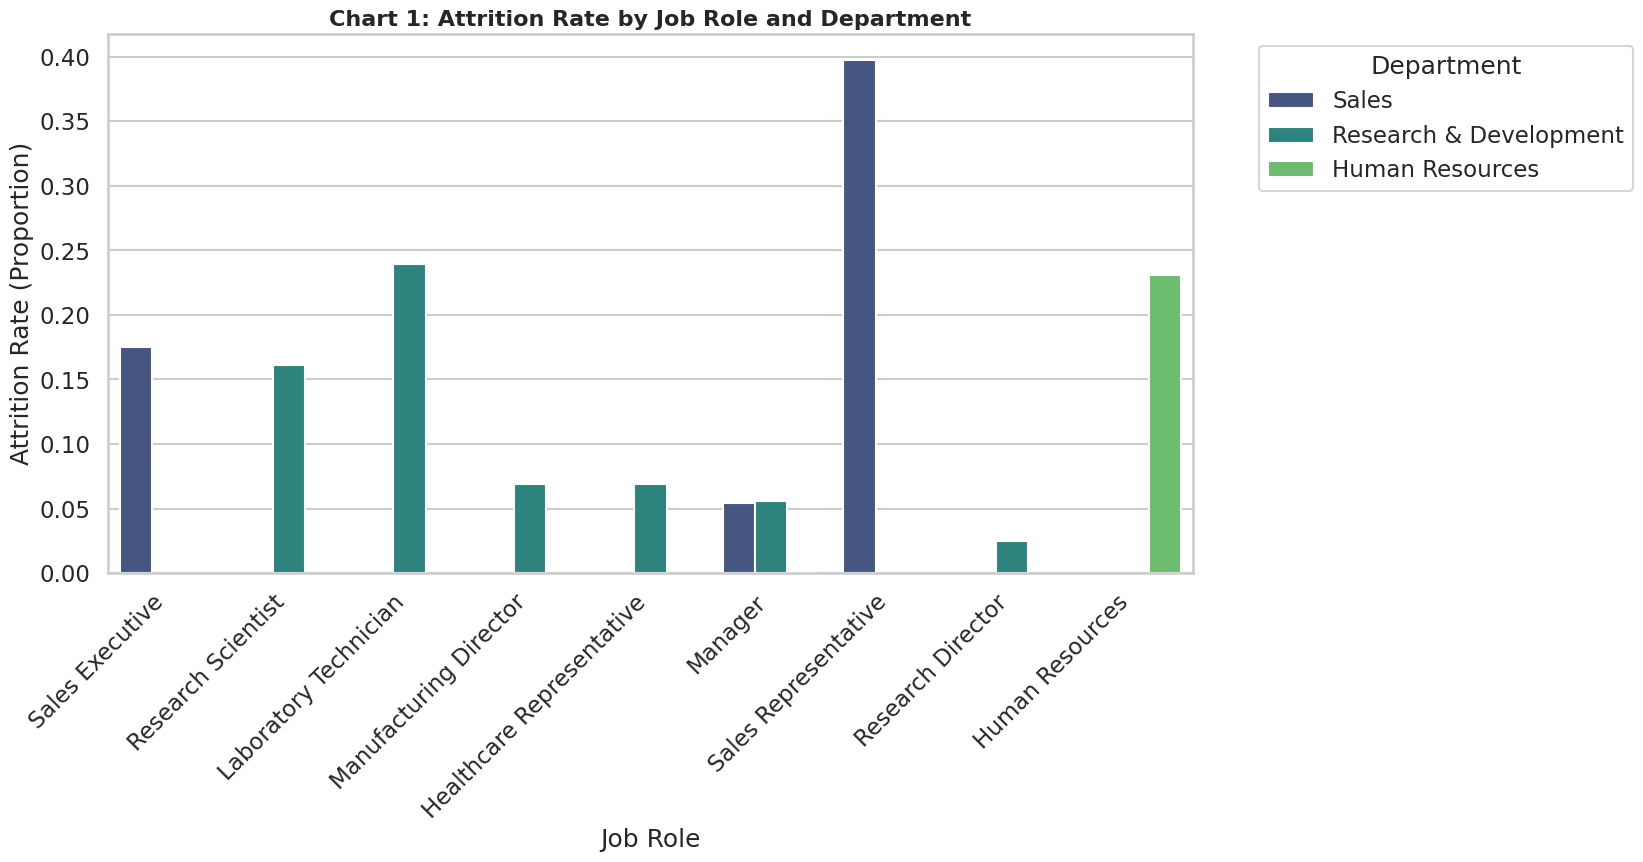

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix
import numpy as np
import pandas as pd

print("--- Task 6: Final Visualizations (Minimum 4 Charts + Bonus) ---")
print("Author: Vaibhav Sharma | Roll No: 102306017 (TIET - ECE)\n")

# Set a professional visual theme
sns.set_theme(style="whitegrid", context="talk")

# --- Chart 1: Bar chart showing attrition rate by Department and Job Role ---
plt.figure(figsize=(14, 7))
sns.barplot(x='JobRole', y='Attrition', hue='Department', data=df_clean, errorbar=None, palette='viridis')
plt.title('Chart 1: Attrition Rate by Job Role and Department', fontsize=16, fontweight='bold')
plt.ylabel('Attrition Rate (Proportion)')
plt.xlabel('Job Role')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('charts/Chart1_Attrition_Dept_JobRole.png', bbox_inches='tight', dpi=300)
plt.show()

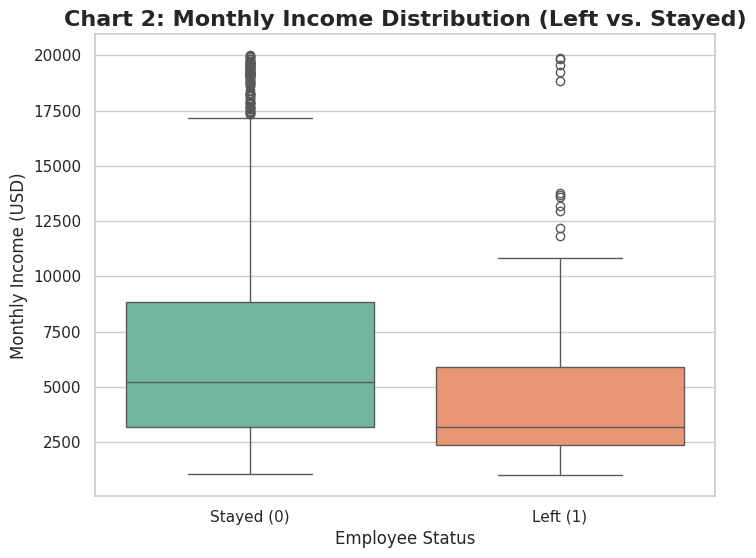

In [ ]:

# --- Chart 2: Box plot comparing Monthly Income of employees who left vs stayed ---
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_clean, hue='Attrition', palette='Set2', legend=False)
plt.title('Chart 2: Monthly Income Distribution (Left vs. Stayed)', fontsize=16, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['Stayed (0)', 'Left (1)'])
plt.ylabel('Monthly Income (USD)')
plt.xlabel('Employee Status')
plt.savefig('charts/Chart2_MonthlyIncome_Comparison.png', bbox_inches='tight', dpi=300)
plt.show()

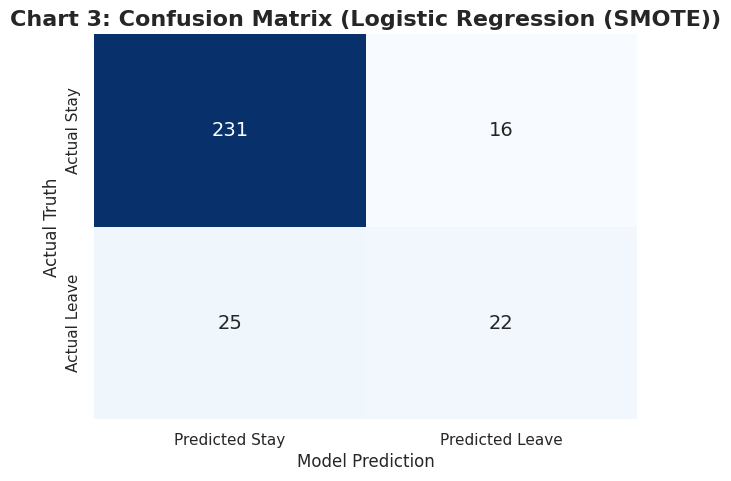

In [ ]:
# --- Chart 3: Confusion Matrix heatmap for your best model ---
# Using the best_model identified dynamically in Task 5 (Logistic Regression)
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14},
            xticklabels=['Predicted Stay', 'Predicted Leave'],
            yticklabels=['Actual Stay', 'Actual Leave'])
plt.title(f'Chart 3: Confusion Matrix ({best_model_name})', fontsize=16, fontweight='bold')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.savefig('charts/Chart3_Confusion_Matrix.png', bbox_inches='tight', dpi=300)
plt.show()

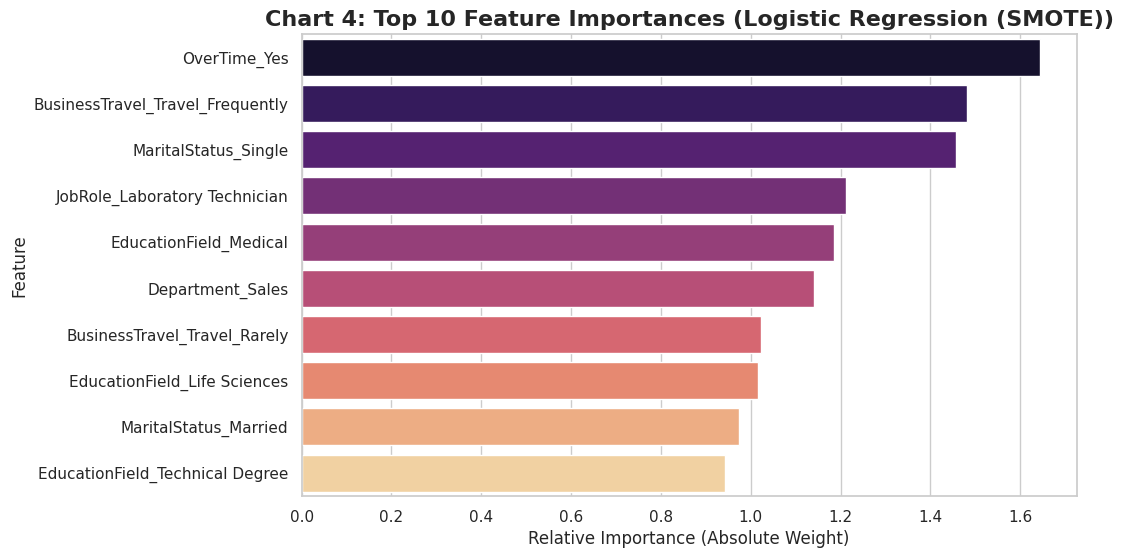

In [ ]:
# --- Chart 4: Horizontal bar chart of Top 10 Feature Importances ---
# Extracting features from our calibrated SMOTE pipeline
base_estimator = best_model.calibrated_classifiers_[0].estimator
if hasattr(base_estimator, 'coef_'):
    importances = np.abs(base_estimator.coef_[0])
else:
    importances = base_estimator.feature_importances_

feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_10_features = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, hue='Feature', palette='magma', legend=False)
plt.title(f'Chart 4: Top 10 Feature Importances ({best_model_name})', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance (Absolute Weight)')
plt.ylabel('Feature')
plt.savefig('charts/Chart4_Top10_Features.png', bbox_inches='tight', dpi=300)
plt.show()

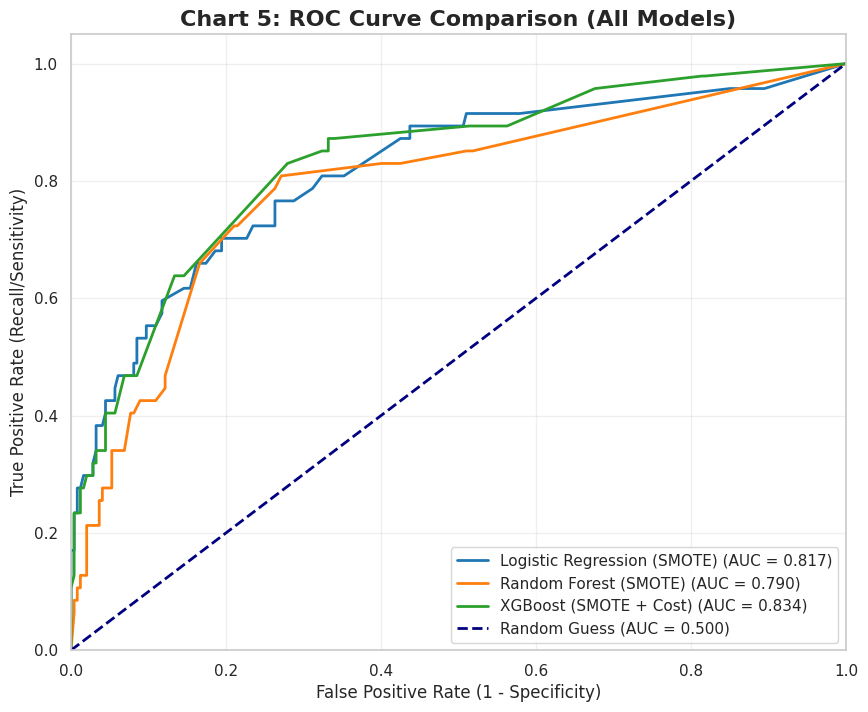

In [ ]:
# --- Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph ---
plt.figure(figsize=(10, 8))

# Loop through all our highly optimized and calibrated models
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for (name, model), color in zip(best_models.items(), colors):
    y_prob_curve = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob_curve)

    # Retrieve the previously calculated ROC-AUC score for the label
    auc_score = results_df[results_df['Model'] == name]['ROC-AUC'].values[0]
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_score:.3f})')

# Add the random guess baseline
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall/Sensitivity)', fontsize=12)
plt.title('Chart 5: ROC Curve Comparison (All Models)', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.savefig('charts/Chart5_ROC_Comparison.png', bbox_inches='tight', dpi=300)
plt.show()

In [2]:
# Install fpdf if you don't have it
!pip install fpdf -q

from fpdf import FPDF

class PDF(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 14)
        self.cell(0, 10, 'Employee Retention Analysis & Strategic Recommendations', 0, 1, 'C')
        self.set_font('Arial', 'I', 10)
        self.cell(0, 10, 'To: Director of Human Resources | From: Vaibhav Sharma (Roll No: 102306017)', 0, 1, 'C')
        self.cell(0, 10, 'Date: June 30, 2026', 0, 1, 'C')
        self.ln(5)

pdf = PDF()
pdf.add_page()
pdf.set_font("Arial", size=11)

# Executive Summary
pdf.set_font("Arial", 'B', 12)
pdf.cell(0, 10, 'Executive Summary', 0, 1)
pdf.set_font("Arial", size=11)
summary_text = (
    "Employee turnover represents a significant hidden cost in hiring, training, and lost productivity. "
    "To address this, we analyzed our historical HR records to identify the hidden patterns that precede "
    "an employee's departure. We have developed a predictive system capable of identifying flight-risk "
    "employees before they leave, allowing HR to pivot from reactive replacements to proactive retention."
)
pdf.multi_cell(0, 6, summary_text)
pdf.ln(5)

# Key Drivers
pdf.set_font("Arial", 'B', 12)
pdf.cell(0, 10, 'Key Drivers of Employee Attrition', 0, 1)
pdf.set_font("Arial", size=11)
drivers_text = (
    "Our analysis revealed that salary is not the primary reason employees leave. Instead, turnover is "
    "strongly driven by burnout and early-career friction. The top three factors are:\n\n"
    "1. Excessive Overtime: Employees who regularly work overtime are at the absolute highest risk of "
    "leaving. Burnout is our most critical vulnerability.\n"
    "2. The 'Two-Year' Danger Zone: We are losing a disproportionate amount of talent during their first "
    "and second years at the company. If an employee stays past year three, their likelihood of leaving "
    "drops dramatically.\n"
    "3. Departmental Strain (Sales): The Sales department, specifically the Sales Representative role, "
    "experiences a turnover rate nearly double that of Research & Development."
)
pdf.multi_cell(0, 6, drivers_text)
pdf.ln(5)

# Recommendations
pdf.set_font("Arial", 'B', 12)
pdf.cell(0, 10, 'Strategic Recommendations', 0, 1)
pdf.set_font("Arial", size=11)
rec_text = (
    "Based on these findings, we recommend implementing the following targeted initiatives:\n\n"
    "* Overtime Audits & Caps: HR should work with department heads to implement a strict review of "
    "overtime distribution. If overtime is unavoidable, we must introduce mandatory recovery days.\n"
    "* Revamp the First-Year Experience: Because the first two years are critical, we should implement "
    "mandatory 'stay interviews' at the 6-month, 12-month, and 18-month marks to catch disengagement "
    "early and course-correct before the employee decides to quit."
)
pdf.multi_cell(0, 6, rec_text)
pdf.ln(5)

# Limitations
pdf.set_font("Arial", 'B',

SyntaxError: incomplete input (2568547049.py, line 66)